In [19]:
import numpy as np
np.random.seed(0)

import scipy
import geogram as geo

In [20]:
def triangle_area(XY, T):
    """
    @brief Computes the area of a mesh triangle
    @param[in] XY the coordinates of the mesh vertices
    @param[in] T an array with the three vertices indices of the triangle
    @details Works also when T is an array of triangles (then it returns
        the array of triangle areas). This is why the ellipsis (...)
        is used (here it means indexing/slicing through the last dimension)
    """
    v1 = T[..., 0]
    v2 = T[..., 1]
    v3 = T[..., 2]

    u = XY[v2] - XY[v1]
    v = XY[v3] - XY[v1]
    return np.abs(0.5 * (u[..., 0] * v[..., 1] - u[..., 1] * v[..., 0]))


def distance(vertices, v1, v2):
    """
    @brief Computes the length of a mesh edge
    @param[in] vertices the coordinates of the mesh vertices
    @param[in] v1, v2 the mesh extremities indices.
    @details v1 and v2 can be also arrays (then returns the array of distances).
    """
    axis = v1.ndim if hasattr(v1, 'ndim') else 0
    return np.linalg.norm(vertices[v2] - vertices[v1], axis=axis)


def hessian(voronoi):
    """
    @brief Assembles the Hessian of the Kantorovich dual
    @param[in] voronoi geo.Voronoi the voronoi diagram
    @return I,J,VAL row,column,value arrays, with the extra-diagonal coeffs
    @details One needs to compute the diagonal (= -sum of extra-diagonal coeffs)
    """
    NO_INDEX = -1  # Special value for invalid indices (edge on border)

    # Compute one entry per triangle half-edge (3*nt entries) with:
    # I is the seed associated with the triangle
    # J is the seed on the other side of the triangle's edge (NO_INDEX on border)
    # V1 and V2 are the two vertices of the triangle
    i = voronoi.tseed

    tadj = voronoi.tadj
    tadj = tadj[:, [1, 2, 0]] # <- permute columns to match std convention for triangulations:
                              #   different in geogram meshes because they also support n-sided polygons
                                      
    j = tadj.T.flatten().astype(np.int32)
    j = np.where(j != NO_INDEX, i[j], NO_INDEX).astype(np.int32)  # lookup seed on other side
    
    i  = np.concatenate((i, i, i))
    v1 = np.concatenate((voronoi.t[:, 1], voronoi.t[:, 2], voronoi.t[:, 0]))
    v2 = np.concatenate((voronoi.t[:, 2], voronoi.t[:, 0], voronoi.t[:, 1]))

    # Remove (i,j,v1,v2) index quadruplets that correspond to
    #   - border triangle edges (j == NO_INDEX)
    #   - triangle edges inside Laguerre cell (i == j)
    qidx = np.column_stack((i, j, v1, v2))
    qidx = qidx[np.logical_and(i != j, j != NO_INDEX)]

    i = qidx[:, 0]  # re-extract i, j, v1, v2
    j = qidx[:, 1]
    v1 = qidx[:, 2]
    v2 = qidx[:, 3]

    # Now we can compute the vector of coefficient (note: v1, v2, i, j are vectors)
    VAL = -distance(voronoi.q, v1, v2) / (2. * distance(voronoi.seeds, i, j))

    return i, j, VAL


def measures(voronoi):
    """
    @brief Computes the measures of the Laguerre cells
    @return the vector of Laguerre cells measures
    @details Uses the current Laguerre diagram (in self.Laguerre)
    """
    # See comments about XY,T,trgl_seed,nt in compute_Laguerre_diagram()
    measures = np.zeros(len(voronoi.seeds))
    np.add.at(measures, voronoi.tseed, triangle_area(voronoi.q, voronoi.t))
    return measures

In [21]:
class Transport:
    def __init__(self, seeds, domain=None, use_direct_solver: bool = False, verbose: bool = False):
        """
        @brief Transport constructor
        @param[in] seeds seeds coordinates
        @param[in] domain Voronoi diagram domain
        @param[in] use_direct_solver: direct (if set) or iterative solver otherwise
        @param[in] verbose log Newton iterations if set
        """

        dimension = seeds.shape[1]
        assert dimension == 2, 'seeds must be a (N, 2) array.'

        self.seeds = seeds
        self.direct = use_direct_solver
        self.verbose = verbose

        self.domain = domain
        if self.domain is None:
            self.domain = geo.shape.quad()

        # Compute Laguerre diagram
        self.psi = np.zeros(len(seeds), np.float64)
        self.voronoi = geo.Voronoi(self.seeds, self.psi, domain_vertices=self.domain[0], domain_simplices=self.domain[1])

        # Measure of whole domain, desired areas and minimum legal area (KMT #1)
        areas = measures(self.voronoi)
        self.omega_measure = np.sum(areas)  # Measure of the whole domain
        self.nu_i = self.omega_measure / len(seeds)  # Desired area for each cell
        self.area_threshold = 0.5 * min(np.min(areas), self.nu_i)  # KMT criterion  #1

        # Parameters for linear solver
        self.regularization = 0.0
        if self.direct:  # if using direct solver, one needs regulariz.
            self.regularization = 1e-6  # because matrix is singular ([1,1...1] in ker)


    def step(self):
        """
        @brief One iteration of Newton-Kitagawa-Merigot-Thibert iteration
        @return the measure error of the worst cell (L_infty norm of gradient)
        """
        H = self.hessian()  # Hessian of Kantorovich dual (sparse matrix)

        # rhs (minus gradient of Kantorovich dual) = desired areas - actual areas
        b = self.nu_i - measures(self.voronoi)
        if self.regularization != 0.0:
            b -= self.regularization * self.nu_i * self.psi

        g_norm = np.linalg.norm(b)  # norm of gradient at current step (KMT #2)
        p = self.solve_linear_system(H, b)  # solve for p in H*p=b
        alpha = 1.0  # Steplength
        self.psi += p  # Start with Newton step

        # Divide steplength by 2 until both KMT criteria are satisfied
        for _ in range(10):
            self.voronoi = geo.Voronoi(self.seeds, self.psi, domain_vertices=self.domain[0], domain_simplices=self.domain[1])

            # g (grad of Kantorovich dual) at substep = actual areas - desired areas
            g = measures(self.voronoi)
            smallest_area = np.min(g)  # for KMT criterion 1
            g -= self.nu_i

            # Check KMT criteria #1 (cell area) and #2 (gradient norm)
            g_norm_k = np.linalg.norm(g)
            kmt_1 = (smallest_area > self.area_threshold)  # criterion 1: cell area
            kmt_2 = (g_norm_k <= (1.0 - 0.5 * alpha) * g_norm)  # criterion 2: gradient norm

            if self.verbose:
                print(f' KMT #1 (area): {kmt_1} {smallest_area}>{self.area_threshold}')
                print(f' KMT #2 (grad): {kmt_2} {g_norm_k}<={(1.0 - 0.5 * alpha) * g_norm}')
                
            if kmt_1 and kmt_2:
                break

            alpha = alpha / 2.0
            self.psi -= alpha * p

        return np.linalg.norm(b, ord=np.inf)  # grad L_infty norm


    def solve_linear_system(self, H, b):
        """
        @brief Solves a linear system
        @details Works in direct or iterative mode, with scipy and with OpenNL
        @param[in] H the matrix of the linear system
        @param[in] b the right hand side
        @return p such that H p = b
        """
        if self.direct:
            p = scipy.sparse.linalg.spsolve(H, b)
        else:
            linalg = scipy.sparse.linalg
            dim = (len(self.seeds), len(self.seeds))

            # A: operator:       y <- (H + diag)*x
            # M: preconditioner: y <- diag@{-1}*x
            self.iter = 0
            p, info = linalg.cg(
                A=linalg.LinearOperator(dim, matvec=lambda x: H @ x + H.diag * x),
                b=b,
                M=linalg.LinearOperator(dim, matvec=lambda x: x / H.diag),
                callback=self.log_iter if self.verbose else None,
                atol=0.0,  # normally the default, but larger on older scipy ver.
                rtol=1e-3  # or tol=1e-3 instead of rtol, depends on scipy ver.
            )
            if info != 0:
                print(f'CG did not converge, info={info}', info)
        return p


    def hessian(self):
        """
        @brief Computes the matrix of the system to be solved at each Newton step
        @details Uses the current Laguerre diagram (in self.Laguerre). Works in
         scipy and in OpenNL mode. In the (scipy,iterative) combination, the
         diagonal of the matrix is stored separately in a dynamically created
         'diag' field of the returned scipy sparse matrix.
        @return the Hessian matrix of the Kantorovich dual
        """

        i, j, val = hessian(self.voronoi)

        n = len(self.seeds)
        diag = np.zeros(n, np.float64)  # Diagonal (initialized to zero)
        np.add.at(diag, i, -val)  # =minus sum extra-diagonal coefficients
        if self.regularization != 0.0:
            diag += self.regularization * self.nu_i

        H = scipy.sparse.csr_array((val, (i, j)), shape=(n, n))
        if self.direct:  # if using direct solver, inject diag coeffs into mtx
            s = np.arange(n, dtype=np.int32)
            H += scipy.sparse.csr_array((diag, (s, s)), shape=(n, n))
        else:
            H.diag = diag  # store diagonal separately if using iterative solver

        return H

In [22]:
N = 500
SHRINK_POINTS = True

# Create points (random sampling of Omega)
seeds = np.random.rand(N, 2)

# To demonstrate more interesting transport, cluster points in a zone
if SHRINK_POINTS:
    seeds = 0.5 + (seeds - .5) * 1e-1

(domain_vertices, domain_triangles) = geo.shape.quad()


In [23]:
import datetime
import matplotlib.tri as tri

starttime = datetime.datetime.now()

optimizer = Transport(seeds, (domain_vertices, domain_triangles))
threshold = optimizer.nu_i * 0.01  # 1% of desired cell area
current_error = np.inf

iteration = 0

plots = []
while current_error > threshold:
    current_error = optimizer.step()

    iteration += 1
    print('Step: {:2d}\tWorst cell area error: {:.6f}'.format(iteration, 100.0 * current_error / optimizer.nu_i))

    triangulation = tri.Triangulation(optimizer.voronoi.q[:, 0], optimizer.voronoi.q[:, 1], optimizer.voronoi.t)
    plots += [ ( triangulation, optimizer.voronoi.tseed ) ]


print('-'*10)
print(f'Total elapsed time for OT: {datetime.datetime.now() - starttime}')
print(f'Converged in {iteration} iterations')

Step:  1	Worst cell area error: 10073.479355
Step:  2	Worst cell area error: 9909.892268
Step:  3	Worst cell area error: 8185.875075
Step:  4	Worst cell area error: 6177.850190
Step:  5	Worst cell area error: 3446.851097
Step:  6	Worst cell area error: 1921.043455
Step:  7	Worst cell area error: 427.847997
Step:  8	Worst cell area error: 69.126878
Step:  9	Worst cell area error: 5.044084
Step: 10	Worst cell area error: 0.059304
----------
Total elapsed time for OT: 0:00:00.061550
Converged in 10 iterations


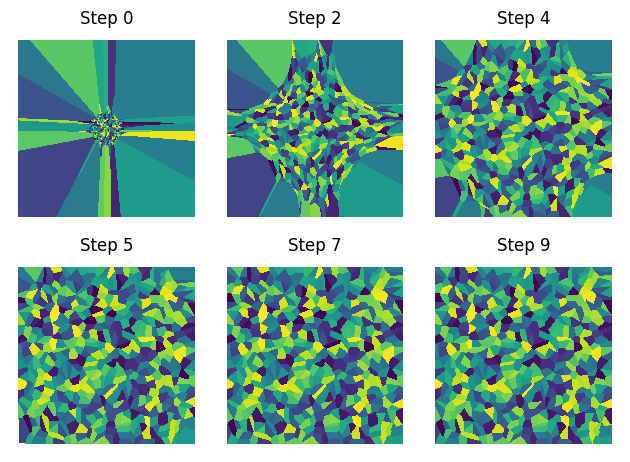

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots( 2, 3 )

indices = np.round(np.linspace(0, iteration - 1, 6)).astype(int)
for n, i in enumerate(indices):
    triangulation, tseed = plots[i]

    axes[n // 3, n % 3].set_aspect('equal')
    axes[n // 3, n % 3].tripcolor(triangulation, tseed, shading='flat')
    axes[n // 3, n % 3].set_title(f'Step {i}')
    axes[n // 3, n % 3].set_axis_off()

fig.tight_layout()